Met Office UK Radar Observations
=========================================================

The Met Office radar data is stored in .h5 files (HDF5 format — Hierarchical Data Format)
Think of an HDF5 file like a filing cabinet: it has groups (drawers) and datasets (folders inside drawers).

```
Bucket : s3://met-office-radar-obs-data  (eu-west-2)
Format : ODIM HDF5  (.h5)
Update : every 15 minutes
Docs   : https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/
         pdf/business/data/external-data/asdi-radar-1km.pdf
```

#### What the Dataset is about:

The UK Radar Rainfall Composite is a national-scale precipitation map created by merging data from 15 individual weather radar stations across the UK and Ireland. It's updated every 15 minutes and archived on AWS S3 with a 2-year rolling window.


From the Met Office factsheet (page 2), the data undergoes several corrections:
- Ground clutter elimination
- Attenuation correction (rain weakening the beam)
- Beam blocking correction (hills obstructing)
- Height correction (beam rises with distance)
- Z-R conversion: radar reflectivity → rainfall rate
- Cartesian conversion: polar radar sweep → square grid cells



In [ ]:
pip install boto3 s3fs h5py numpy matplotlib

## Exploring the File Structure

-  Open the file and explore what's inside it

In [ ]:
import h5py

file_path = "/content/drive/MyDrive/Dissertation/202411210930_ODIM_ng_radar_rainrate_composite_1km_UK.h5"


def explore_group(group, indent=0):
    """
    Recursively prints everything inside an HDF5 group.

    Parameters:
        group  : an h5py Group object (think: a folder)
        indent : how many spaces to indent (increases as we go deeper)
    """
    prefix = "  " * indent  # e.g. "    " at depth 2

    for key in group.keys():           # loop over everything in this group
        item = group[key]              # get the item by name

        if isinstance(item, h5py.Group):
            # It's a folder — print it, then recurse INTO it
            print(f"{prefix}📁 GROUP: {key}")
            explore_group(item, indent + 1)   # ← go one level deeper

        elif isinstance(item, h5py.Dataset):
            # It's actual data — print its name, shape, and type
            print(f"{prefix}📄 DATASET: {key}")
            print(f"{prefix}     shape : {item.shape}")
            print(f"{prefix}     dtype : {item.dtype}")

            # Also print any attributes attached to this dataset
            # Attributes are metadata — like labels on a jar
            if len(item.attrs) > 0:
                for attr_key, attr_val in item.attrs.items():
                    print(f"{prefix}     attr  → {attr_key}: {attr_val}")


# ── Open and explore ───────────────────────────────────────────────────────
# We open the file, do ALL our work inside the with block,
# and only close it at the end. No nested functions that might
# confuse the file handle.

with h5py.File(file_path, "r") as f:

    print("=== FILE STRUCTURE ===\n")
    explore_group(f)       # start at the root, indent=0

    # ── Root-level attributes ──────────────────────────────────────────────
    # The root "/" group often has file-level metadata attached to it
    print("\n=== ROOT ATTRIBUTES ===\n")
    if len(f.attrs) > 0:
        for key, val in f.attrs.items():
            print(f"  {key}: {val}")
    else:
        print("  (no root attributes found)")

=== FILE STRUCTURE ===

📁 GROUP: dataset1
  📁 GROUP: data1
    📄 DATASET: data
         shape : (2175, 1725)
         dtype : float32
    📁 GROUP: what
  📁 GROUP: how
  📁 GROUP: what
📁 GROUP: how
📁 GROUP: what
📁 GROUP: where

=== ROOT ATTRIBUTES ===

  Conventions: b'ODIM_H5/V2_2'


The where, what, and how groups are standard ODIM metadata.

They tell you where the grid is, what the numbers mean, and how the data was collected.

In [ ]:
"""
202411210930_ODIM_ng_radar_rainrate_composite_1km_UK.h5
│   │   │  │  │    │      │         │        │   │
│   │   │  │  │    │      │         │        │   └── Domain: UK-wide
│   │   │  │  │    │      │         │        └────── Resolution: 1km grid
│   │   │  │  │    │      │         └─────────────── Product: rainrate composite
│   │   │  │  │    │      └───────────────────────── Source: Next Generation (ng)
│   │   │  │  │    └──────────────────────────────── Format: ODIM HDF5
│   │   │  │  └──────────────────────────────────── Time: 09:30 UTC
│   │   │  └─────────────────────────────────────── Date: 21 November 2024
│   │   └────────────────────────────────────────── Year prefix (sometimes used in keys)
│   └───────────────────────────────────────────── Month
└───────────────────────────────────────────────── Day


📁 dataset1          ← one "scan" / one moment in time
  📁 data1           ← the actual rainfall product
    📄 data          ← THE GRID: 2175 rows × 1725 columns of float32 values
    📁 what          ← metadata about THIS dataset (gain, nodata, offset)
  📁 how             ← HOW this scan was made (algorithm, etc.)
  📁 what            ← WHAT quantity this is (start time, end time, etc)
📁 how               ← file-level "how"
📁 what              ← file-level "what" (date, time, source)
📁 where             ← WHERE geographically (grid origin, pixel size, projection)
"""


"""
dataset1/data1/data     :     The 2D rainfall grid — this IS the radar image
(2175, 1725)      :    2175 rows (North→South) × 1725 columns (West→East) covering the UK at 1km per pixel
where    :         Contains the grid's geographic coordinates so you can plot it on a map
what    :      Contains the timestamp, units, nodata/fill values
"""

## Reading the Metadata Properly

In [ ]:
with h5py.File(file_path, "r") as f:

    # ── "what" groups tell you WHAT the numbers mean ───────────────────────
    # There are two: one at file level, one at dataset level.
    # We want both.

    print("=== FILE-LEVEL 'what ===\n")
    for key, val in f["what"].attrs.items():
        print(f"  {key}: {val}")

    print("\n=== DATASET-LEVEL 'what' ===\n")
    for key, val in f["dataset1"]["what"].attrs.items():
        print(f"  {key}: {val}")

    print("\n=== 'where' (geographic grid info) ===\n")
    for key, val in f["where"].attrs.items():
        print(f"  {key}: {val}")

    print("\n=== dataset1/data1/what (per-array metadata) ===\n")
    for key, val in f["dataset1"]["data1"]["what"].attrs.items():
        print(f"  {key}: {val}")

=== FILE-LEVEL 'what' (date, time, source) ===

  date: b'20241121'
  object: b'COMP'
  source: b'WMO:03523,WMO:03331,WMO:03675,WMO:03962,WMO:03918,WMO:03813,WMO:03375,WMO:03601,WMO:03897,WMO:03086,WMO:03018,WMO:03142,WMO:03771,WMO:03859,WMO:03253'
  time: b'093000'
  version: b'H5rad 2.2'

=== DATASET-LEVEL 'what' (units, gain, offset, nodata) ===

  enddate: b'20241121'
  endtime: b'092944'
  product: b'COMP'
  startdate: b'20241121'
  starttime: b'092842'

=== 'where' (geographic grid info) ===

  LL_lat: 43.83405184575088
  LL_lon: -12.011794919778003
  LR_lat: 43.70087658067965
  LR_lon: 9.415780820163617
  UL_lat: 62.92071695962483
  UL_lon: -17.973932221553792
  UR_lat: 62.651484803966376
  UR_lon: 16.128870790695817
  projdef: b'+proj=tmerc +lat_0=49 +lon_0=-2 +k=0.999601 +x_0=400000 +y_0=-100000 +ellps=airy +units=m'
  xscale: 1000.0
  xsize: 1725
  yscale: 1000.0
  ysize: 2175

=== dataset1/data1/what (per-array metadata) ===

  gain: 1.0
  nodata: -1.0
  offset: 0.0
  quanti

### INPUTS AND OUTPUTS

#### Input to the model:
- Raw array: dataset1/data1/data — shape (2175, 1725) of float32
- Values should be mm/hr
- Critical Masking:
  - nodata = -1.0 → radar couldn't see this area → must mask as NaN
  - undetect = 0.0 → radar looked, no rain detected → genuinely dry (0 mm/hr)

#### Output
- A georeferenced rainfall intensity map of the UK
- Each pixel = 1km × 1km area
- Color = instantaneous rainfall rate in mm/hour (not total accumulation)
- Geographic coordinates properly projected using Transverse Mercator (British National Grid)

For nowcasting, you'll typically use sequences like:
- Input: 4 frames (1 hour of history) → 0930, 0945, 1000, 1015
- Target: 1 frame (15-min ahead) → 1030

Or for longer nowcasts:
- Input: 8 frames (2 hours) → 0930 to 1045
- Target: 4 frames (1 hour ahead) → 1100 to 1145

The gain, offset, nodata, and undetect values in the what groups are essential — they tell you how to convert raw pixel values into actual mm/hour.

## Key Dataset Parameters

### File Identity
- **date / time**: Observation timestamp — `20241121` at `09:30:00 UTC` (21 November 2024, 9:30am)
- **object: COMP**: This is a *composite* — rainfall from all UK radar stations merged into one national image
- **source**: The 15 individual WMO radar stations that contributed to this composite
- **version: H5rad 2.2**: Follows the ODIM HDF5 v2.2 standard for European radar data exchange

### The Grid - Geographic Coverage (`where`)
- **xsize / ysize**: The grid is **1725 columns × 2175 rows** — one pixel per km, covering the whole UK
- **xscale / yscale: 1000.0**: Each pixel represents a **1km × 1km** area on the ground
- **projdef**: The map projection used — **Transverse Mercator** (the same as British National Grid), centred on lon=-2, lat=49
- **LL/LR/UL/UR lat-lon**: The four corner coordinates of the grid — spanning roughly **43.7°N to 62.9°N** and **-18°W to 16°E**

### The Data Values (`dataset1/data1/what`)
- **quantity: RATE**: Each pixel value is an instantaneous **rainfall rate in mm/hour**
- **gain: 1.0**: No rescaling needed — raw values are already in mm/hour (gain of 1 means multiply by 1)
- **offset: 0.0**: No offset shift needed — formula is simply `real_value = (raw_value × gain) + offset`
- **nodata: -1.0**: Pixels with value `-1.0` mean **no data available** (e.g. outside radar coverage) — must be masked out before analysis
- **undetect: 0.0**: Pixels with value `0.0` mean the radar looked but detected **no rainfall** — genuinely dry areas

### Critical distinction
- `undetect (0.0)` = radar saw nothing → **dry**
- `nodata (-1.0)` = radar couldn't see there → **unknown** — treat differently in analysis

### The HDF5 Structure (ODIM Standard)
| Group                      | Purpose               | What's Inside                                                                          |
| -------------------------- | --------------------- | -------------------------------------------------------------------------------------- |
| **`/what`**                | File identity         | date, time, object type, source stations, ODIM version                                 |
| **`/where`**               | Geographic grid       | projection (Transverse Mercator), pixel size (1000m), grid dimensions, corner lat/lons |
| **`/how`**                 | Processing info       | algorithm details, quality control steps                                               |
| **`/dataset1`**            | One time scan         | Contains the actual rainfall data for this timestamp                                   |
| **`/dataset1/data1/data`** | **The rainfall grid** | 2175 × 1725 array of float32 values — **this is your input**                           |
| **`/dataset1/what`**       | Dataset metadata      | quantity type, timestamp                                                               |
| **`/dataset1/data1/what`** | Array metadata        | **gain, offset, nodata, undetect** — critical for interpretation                       |


NOTE:

The single most important thing to remember going forward: always mask nodata = -1.0 before doing any calculations, otherwise your mean rainfall, max values etc. will be completely wrong.

In [ ]:
# ── CELL: Install pysteps ─────────────────────────────────────────────────
!pip install pysteps --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.3/678.3 kB 15.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ── CELL: Load with pySTEPS — lets it handle all the projection maths ─────
from pysteps.io.importers import import_odim_hdf5
from pysteps.visualization.precipfields import plot_precip_field
import matplotlib.pyplot as plt
import numpy as np

file_path = "/content/drive/MyDrive/Dissertation/202411210930_ODIM_ng_radar_rainrate_composite_1km_UK.h5"

# import_odim_hdf5 returns three things:
#   rain_pysteps : the 2D rainfall array (mm/hr), already masked
#   quality      : a quality/confidence array (often None)
#   metadata     : a dictionary with ALL geographic and unit info resolved
#
# The key argument is qty="RATE" — tells it we want rain rate, not reflectivity

rain_pysteps, quality, metadata = import_odim_hdf5(file_path, qty="RATE")

# ── Inspect what pySTEPS extracted ────────────────────────────────────────
print("=== ARRAY ===")
print(f"  Shape      : {rain_pysteps.shape}")
print(f"  dtype      : {rain_pysteps.dtype}")
print(f"  Min        : {np.nanmin(rain_pysteps):.3f}")
print(f"  Max        : {np.nanmax(rain_pysteps):.3f}")

print("\n=== METADATA (everything pySTEPS resolved for us) ===")
for key, val in metadata.items():
    print(f"  {key:20s} : {val}")

Pysteps configuration file found at: /usr/local/lib/python3.12/dist-packages/pysteps/pystepsrc

=== ARRAY ===
  Shape      : (2175, 1725)
  dtype      : float64
  Min        : 0.000
  Max        : 41.553

=== METADATA (everything pySTEPS resolved for us) ===
  projection           : +proj=tmerc +lat_0=49 +lon_0=-2 +k=0.999601 +x_0=400000 +y_0=-100000 +ellps=airy +units=m
  ll_lon               : -12.011794919778003
  ll_lat               : 43.83405184575088
  ur_lon               : 16.128870790695817
  ur_lat               : 62.651484803966376
  x1                   : -404999.97200176364
  y1                   : -625000.027417512
  x2                   : 1319999.9046300563
  y2                   : 1549999.368383532
  xpixelsize           : 1000.0
  ypixelsize           : 1000.0
  cartesian_unit       : m
  yorigin              : upper
  institution          : Odyssey datacentre
  accutime             : 15.0
  unit                 : mm/h
  transform            : None
  zerovalue        

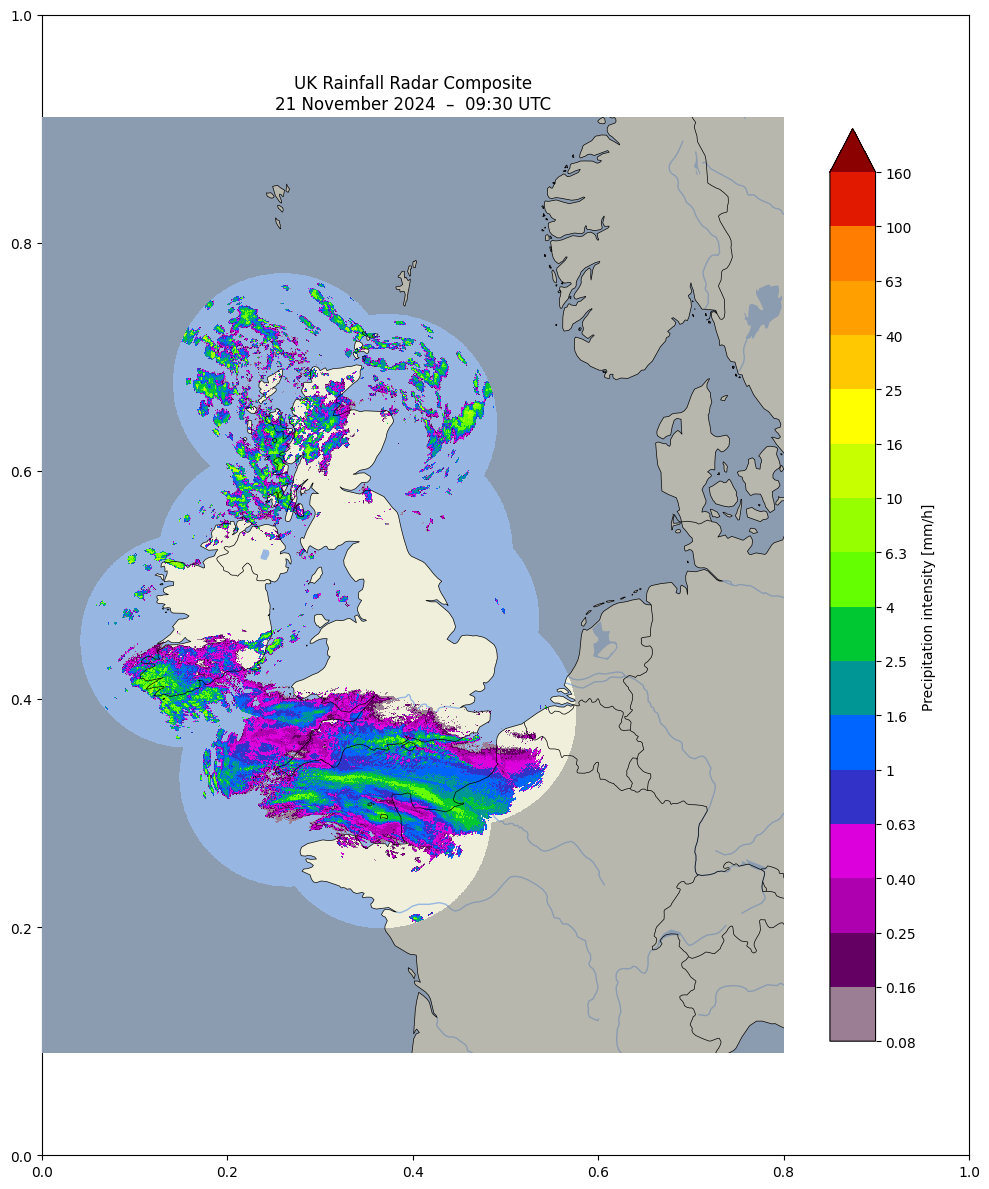


=== GEODATA USED FOR PLOTTING ===
  x1 (left)   : -405,000 m
  x2 (right)  : 1,320,000 m
  y1 (bottom) : -625,000 m
  y2 (top)    : 1,549,999 m
  projection  : +proj=tmerc +lat_0=49 +lon_0=-2 +k=0.999601 +x_0=400000 +y_0=-100000 +ellps=airy +units=m


In [ ]:
# ── CELL: Plot with pySTEPS built-in visualiser ───────────────────────────
# plot_precip_field() knows about ODIM projections and handles
# the coordinate transform internally.
#
# geodata is the key — it's the geographic info pySTEPS extracted,
# telling the plotter exactly where each pixel sits.

fig, ax = plt.subplots(figsize=(10, 12))

plot_precip_field(
    rain_pysteps,
    geodata=metadata,        # ← this is what fixes the alignment
    units="mm/h",
    title="UK Rainfall Radar Composite\n21 November 2024  –  09:30 UTC",
    axis="on",
    ax=ax
)

plt.tight_layout()
plt.savefig("uk_radar_pysteps.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print the geodata so we can see what coords pySTEPS is using ──────────
print("\n=== GEODATA USED FOR PLOTTING ===")
print(f"  x1 (left)   : {metadata['x1']:,.0f} m")
print(f"  x2 (right)  : {metadata['x2']:,.0f} m")
print(f"  y1 (bottom) : {metadata['y1']:,.0f} m")
print(f"  y2 (top)    : {metadata['y2']:,.0f} m")
print(f"  projection  : {metadata['projection']}")

| Color          | Intensity          | Meaning                     |
| -------------- | ------------------ | --------------------------- |
| Grey/White     | 0 mm/hr or no data | Dry land or nodata areas    |
| Purple/Magenta | 0.08–0.63 mm/hr    | Very light rain/drizzle     |
| Blue           | 1–2.5 mm/hr        | Light rain                  |
| Green          | 4–10 mm/hr         | Moderate rain               |
| Yellow/Orange  | 16–40 mm/hr        | Heavy rain                  |
| Red/Dark Red   | 63–160+ mm/hr      | Very heavy/intense rainfall |


### What this data is representing:

| Scenario                                    | What You'd See                                                                        |
| ------------------------------------------- | ------------------------------------------------------------------------------------- |
| **Clear day nationwide**                    | Mostly white/grey with scattered purple (0.08 mm/hr = radar noise/drizzle)            |
| **Frontal rain crossing UK**                | Broad bands of green/yellow (10–40 mm/hr) moving west→east over 6–12 hours            |
| **Thunderstorm cell**                       | Small, intense red/dark red spot (100+ mm/hr) lasting 15–30 minutes                   |
| **Orographic enhancement**  | Enhanced rainfall (brighter colors) on windward side of hills, shadow on leeward side |
| **Bright band error**          | False ring of heavy rain around melting level in winter, this needs correction            |
| **Radar gap**                               | Black/white wedge where terrain blocks beam    |


# Streaming from AWS S3

This script does 4 things:
- Connects to S3 anonymously
- Lists files to discover the directory structure
- Batch downloads a sequence of 4 frames
- Loads it with h5py

In [ ]:
pip install boto3 s3fs h5py

INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/

In [ ]:
import boto3  #The official AWS SDK. We use it for listing and downloading.
from botocore import UNSIGNED
from botocore.config import Config
import h5py
import numpy as np
import os


In [ ]:
# STEP 1: Configure boto3 for ANONYMOUS access
# =============================================================================
# By default, boto3 tries to find your AWS access keys (from environment
# variables, ~/.aws/credentials, etc.). Since this is public data, we tell it
# explicitly: "Do not sign this request. No authentication needed.

s3 = boto3.client(
    's3',
    region_name='eu-west-2',           # The bucket lives in London
    config=Config(signature_version=UNSIGNED)  # Anonymous access
)

BUCKET_NAME = 'met-office-radar-obs-data'

In [ ]:
# STEP 2: Discover the bucket structure (LISTING)
# =============================================================================
#
# Let's list a few objects to find out. We use list_objects_v2 with a prefix
# to limit results (otherwise we might get millions of files).

print("=== DISCOVERING BUCKET STRUCTURE ===\n")


response = s3.list_objects_v2(
    Bucket=BUCKET_NAME,
    MaxKeys=10
)
if 'Contents' in response:
    for obj in response['Contents']:
        print(f"  {obj['Key']}  ({obj['Size'] / 1024:.1f} KB)")
else:
    print("Bucket appears empty or you may need a different prefix.")

=== DISCOVERING BUCKET STRUCTURE ===

  index.html  (35.0 KB)
  radar/2024/11/21/202411210930_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1407.1 KB)
  radar/2024/11/21/202411210945_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1396.1 KB)
  radar/2024/11/21/202411211000_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1384.5 KB)
  radar/2024/11/21/202411211015_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1352.7 KB)
  radar/2024/11/21/202411211030_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1319.3 KB)
  radar/2024/11/21/202411211045_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1294.4 KB)
  radar/2024/11/21/202411211100_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1274.4 KB)
  radar/2024/11/21/202411211115_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1240.2 KB)
  radar/2024/11/21/202411211130_ODIM_ng_radar_rainrate_composite_1km_UK.h5  (1211.6 KB)


### Directory Structure:

Files live under radar/YYYY/MM/DD/

The full s3 key is:
```
radar/2024/11/21/202411210930_ODIM_ng_radar_rainrate_composite_1km_UK.h5
```
-----
### Timestamps:
Looking at the time, the data keeps updating every 15 minutes. This is the "heartbeat" of the dataset.

For nowcasting, you'll typically use sequences like:
- Input: 4 frames (1 hour of history) → 0930, 0945, 1000, 1015
- Target: 1 frame (15-min ahead) → 1030

Or for longer nowcasts:
- Input: 8 frames (2 hours) → 0930 to 1045
- Target: 4 frames (1 hour ahead) → 1100 to 1145

----
### File Sizes vary slightly:
Notice the sizes drop from 1407 KB → 1211 KB. Why?
This is actually meteorologically interesting. HDF5 files compress the data. When there's lots of rain (high entropy, complex spatial patterns), compression is less efficient → larger files. When it's drier or more uniform, compression is better → smaller files. The file size is a rough proxy for how "interesting" the weather was!

# Part 2 — From Radar Frames to an Advection Prior

Everything above was *exploration*: understanding one ODIM file, its metadata, and how to stream from S3. From here we build the actual **research pipeline**. This part delivers everything up to and including the **advection prior** — the physical "first guess" that the diffusion model will later correct.

### The idea in one line (residual decomposition)

This project follows the **Reynolds / residual decomposition** used by CorrDiff (Mardani et al. 2025) and DiffCast (Yu et al. 2024):

$$\underbrace{y}_{\text{true future rain}} \;=\; \underbrace{A}_{\text{advection prior (physics, prescribed)}} \;+\; \underbrace{r}_{\text{residual (growth, decay, fine detail)}}$$

- **$A$** = a *prescribed, non-learned* semi-Lagrangian advection nowcast (pysteps). It captures the easy, large-scale part: "rain moves with the wind." This is interpretable physics.
- **$r = y - A$** = the leftover that advection *cannot* produce — initiation, growth, decay, and small-scale texture. This is the *only* thing the latent diffusion model has to learn. A zero-mean, lower-variance target converges faster and gives sharper detail than modelling the whole field (the CorrDiff/DiffCast argument).

So our two experimental arms are:
1. **Advection-only baseline** — use $A$ as the forecast. (Built in this Part.)
2. **Full physics-informed model** — $\hat{y} = A + \hat{r}$, where $\hat{r}$ is sampled from the LDM. (Built later.)

### Where this runs: the Exeter compute servers

This pipeline now targets the **University of Exeter undergraduate compute servers** (`mcrugcomp01/02/03.ex.ac.uk`): 64-core AMD EPYC, 384 GB RAM, an **NVIDIA L4 (24 GB)** GPU each, and a **13 TB local `/scratch`**. We moved off Colab because Colab's Drive cache is ephemeral and unreliable for many files; the server gives us a *persistent, fast* filesystem and 64 cores to parallelise the advection over. The advection prior itself is **CPU work** (pysteps) — the L4 is reserved for the diffusion stage. The full build is run headless by **`build_advection_prior.py`** (see §2.11); this notebook documents the design and runs a small smoke test.

### ⚠️ Data-availability constraint (important — discovered by probing the bucket)

The S3 bucket keeps only a **~19-month rolling window**. Probing it live gives:

| Year | Months actually present on S3 |
|------|-------------------------------|
| 2024 | **November (from the 21st) and December only** |
| 2025 | January – December (full) |
| 2026 | January onward (ongoing) |

The earliest frame that exists is `2024-11-21 09:30`. **"2024 full" (the original DGMR-style plan) is therefore impossible.** We keep the DGMR *split philosophy* but adapt the dates to what exists, and for now work on a **6-month initial subset (2024-11-21 → 2025-04-30)**:

| Split | Definition (DGMR-style, adapted) | This subset |
|-------|----------------------------------|-------------|
| **Train** | all days except the first 2 of each month | most of 2024-11-21 → 2025-04-30 |
| **Validation** | the **first 2 days** of each month (or first available) | ~12 days |
| **Test** | the held-out future year | 2026 (not in this subset) |

No importance sampling yet (planned as an ablation), exactly as agreed.

### Roadmap for this Part
1. **Config** — every hyperparameter in one place.
2. **S3 access** — `boto3` whole-file reads (no raw files kept in memory longer than needed).
3. **Temporal sampling** — 4 input frames → 1 target at **+60 min**.
4. **Train/val/test split** — the adapted DGMR split (val = first 2 days of the month).
5. **Spatial cropping** — 256×256 land crops, with a motion margin so advection inflow is handled.
6. **Cache** — compact crops + advection prior on `/scratch`.
7. **Advection prior + residual** — pysteps optical flow + semi-Lagrangian extrapolation → cache `A` and `r`.

## 2.0 Design decisions at a glance

Per the supervision style of this project, **every** non-trivial choice is recorded with the alternatives considered. The big ones for this Part:

| # | Decision | Chosen | Alternatives (and why not, for now) |
|---|----------|--------|--------------------------------------|
| 1 | **Compute / storage** | **Exeter `mcrugcomp` server + `/scratch`** (persistent, fast, 64 cores) | Colab + Drive (cache was ephemeral — what we moved *away* from); local GPU workstation |
| 2 | **S3 access** | `boto3` whole-file download | `s3fs` streaming (h5py random seeks over HTTP are slow, re-paid every epoch) |
| 3 | **Data scope now** | **6-month subset** (2024-11-21 → 2025-04-30) | full 2024-11→2025-12 range (later); fixed case studies |
| 4 | **Domain / resolution** | **256×256** crops @ 1 km | full UK 2175×1725 (too heavy for an LDM); 2 km downsample (loses convection) |
| 5 | **Forecast setup** | 4 inputs @ 15 min → **single target at +60 min** | predict the full +15…+60 sequence (later); shorter/longer lead |
| 6 | **Advection engine** | pysteps dense **Lucas–Kanade** + backward **semi-Lagrangian** | VET (variational, accurate but slow); DARTS (spectral) — both noted in PySteps.docx |
| 7 | **Transform for advection** | **dBR** log-transform (pysteps standard) | linear mm/h (heavy-tailed, poor for motion + diffusion); normalised [0,1] |
| 8 | **Residual space** | residual computed in **dBR** | residual in mm/h (heavy-tailed → harder for diffusion) |
| 9 | **Validation rule** | **first 2 days** of each month | first 1 day (fewer val samples); random split (leakage risk) |
| 10 | **Scale-out** | download frames once, then **advect in parallel across all cores** | per-sample re-streaming (network-bound); single-process (slow) |

Items 1–4, 9 were confirmed with the supervisor. Items 5–8, 10 follow the literature notes (PySteps.docx, DGMR.docx, Physical Scales Matter, DiffCast/CorrDiff) and are documented again at the relevant cell.

In [ ]:
# ── CELL: Environment setup (Exeter compute server) ───────────────────────
# Dependencies come from the conda env (environment.yml): pysteps, boto3, h5py,
# numpy, matplotlib, tqdm. No Colab, no Google Drive — the heavy cache lives on
# the server's fast /scratch and persists between sessions.
#
#   conda env create -f environment.yml   &&   conda activate nowcast

import io, os, sys, glob, getpass, datetime as dt
from types import SimpleNamespace
from collections import Counter

import numpy as np
import h5py
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from botocore.exceptions import ClientError

USER = getpass.getuser()
# Fast local /scratch on the server (13 TB, NOT backed up). Falls back to a
# local folder when running off-server (e.g. a laptop smoke test).
_scratch = f"/scratch/{USER}"
SCRATCH_BASE = _scratch if os.path.isdir(_scratch) else os.path.abspath("./diss_scratch")
ON_SERVER = os.path.isdir(_scratch)

print(f"user={USER}  on_server={ON_SERVER}  cpu_cores={os.cpu_count()}")
print(f"scratch base: {SCRATCH_BASE}")
if not ON_SERVER:
    print("NOTE: /scratch not found — running off-server; caching locally.")

## 2.1 Configuration

A single source of truth for every tunable. Keeping these in one namespace (rather than scattered magic numbers) is what makes the pipeline reproducible and the dissertation's ablations easy — to change the lead time or crop size we edit exactly one place.

A few choices worth justifying here:

- **`n_input = 4`, `cadence_min = 15`** → 4 frames span the **last hour** of observations. DGMR (and our notes) found 4 frames sufficient; 6–8 gave "no appreciable improvement."
- **`lead_min = 60`** → we predict the frame **exactly one hour ahead** of the last observation. At 15-min cadence that is `n_leadtimes = 4` advection steps, and **we keep only the final (+60 min) frame**.
- **`crop = 256`, `margin = 64`** → the model sees 256×256 km, but advection runs on a **384×384** context so rain flowing *into* the crop from outside is represented. A 60-min nowcast of a 15 m/s storm travels ~54 km ≈ 54 px, so a 64-px margin covers typical inflow.
- **`subset_start/end`** → the 6-month window (2024-11-21 → 2025-04-30). The full headless run uses these; the in-notebook smoke test below uses a short slice for speed.
- **`val_days = 2`** → the first 2 days of each month are validation (DGMR-style, widened from 1 to 2).
- **`n_workers`** → processes for the parallel advection (defaults to cores − 4, leaving headroom).

In [ ]:
# ── CELL: Master configuration ────────────────────────────────────────────
CFG = SimpleNamespace(
    # --- S3 source ---
    bucket="met-office-radar-obs-data", region="eu-west-2",
    fname_suffix="_ODIM_ng_radar_rainrate_composite_1km_UK.h5",

    # --- temporal sampling ---
    cadence_min=15, n_input=4, lead_min=60,

    # --- spatial domain ---
    crop=256, margin=64, stride=256,

    # --- masking / units (from ODIM metadata; see Part 1) ---
    rain_thresh_mmh=0.1, cap_mmh=128.0,

    # --- crop acceptance filters ---
    min_valid_frac=0.90, min_rain_frac=0.05,

    # --- dBR transform (pysteps standard) ---
    dbr_thresh=0.1, dbr_zero=-15.0, dbr_inv_thr=-10.0,

    # --- 6-month initial subset (Nov 2024 -> Apr 2025) ---
    subset_start="2024-11-21", subset_end="2025-04-30",
    max_samples=600,            # cap for the QUICK in-notebook test only

    # --- split (adapted DGMR) ---
    test_year=2026, val_days=2,  # first 2 days of each month -> validation

    # --- parallelism (used by build_advection_prior.py) ---
    n_workers=max(1, (os.cpu_count() or 8) - 4),
    io_workers=32,
)

# derived quantities + cache layout on /scratch
CFG.context     = CFG.crop + 2 * CFG.margin            # 384
CFG.n_leadtimes = CFG.lead_min // CFG.cadence_min       # 4 advection steps to +60 min
CFG.root        = os.path.join(SCRATCH_BASE, "dissertation")
CFG.frames      = os.path.join(CFG.root, "frames")               # raw .h5 cache (script)
CFG.cache_s1    = os.path.join(CFG.root, "cache", "stage1_seq")  # clean mm/h crops
CFG.cache_s2    = os.path.join(CFG.root, "cache", "stage2_prior")# A, r
for _d in (CFG.frames, CFG.cache_s1, CFG.cache_s2):
    os.makedirs(_d, exist_ok=True)

print(f"context window : {CFG.context}x{CFG.context} px  (crop {CFG.crop} + 2x margin {CFG.margin})")
print(f"lead           : +{CFG.lead_min} min  =>  {CFG.n_leadtimes} semi-Lagrangian steps, keep last")
print(f"subset         : {CFG.subset_start} .. {CFG.subset_end}   (val = first {CFG.val_days} days/month)")
print(f"workers        : {CFG.n_workers} process / {CFG.io_workers} io")
print(f"cache root     : {CFG.root}")

## 2.2 S3 access layer (boto3, whole-file reads)

**Why boto3 and not s3fs (decision #2).** We always read the *entire* `dataset1/data1/data` array from each file, so there is no benefit to lazy/partial reads. `s3fs` would let h5py seek around the file over HTTP — and each seek is a fresh network round-trip, re-paid on every epoch. Instead we issue **one** `get_object` per file. On the server, the full build downloads each `.h5` once to `/scratch/.../frames` (fast local disk) and then everything reads from there — this is what `build_advection_prior.py` does. In this notebook the helpers read straight into memory for the smoke test.

The functions below are deliberately small and pure so they are easy to unit-test:
- `radar_key(dt)` — deterministic S3 key from a timestamp.
- `read_odim_rainrate(buf)` — bytes → masked `mm/h` array (applies `gain`/`offset`, masks `nodata` → NaN, sets `undetect` → 0). The **single most important rule from Part 1**: always mask `nodata` before any maths.
- `fetch_frame(dt)` — key → array, returning `None` for missing frames (so the sampler can skip gaps).
- `list_day_keys(date)` — one listing per day, to know which timestamps exist without a HEAD per frame.

In [ ]:
# ── CELL: boto3 client + low-level readers ────────────────────────────────
# Anonymous client (public dataset) — same config as the exploration cells.
s3 = boto3.client("s3", region_name=CFG.region,
                  config=Config(signature_version=UNSIGNED))
BUCKET = CFG.bucket


def radar_key(t: dt.datetime) -> str:
    """Deterministic S3 key for a given UTC timestamp."""
    return f"radar/{t:%Y/%m/%d}/{t:%Y%m%d%H%M}{CFG.fname_suffix}"


def read_odim_rainrate(buf: bytes) -> np.ndarray:
    """Decode ODIM HDF5 bytes -> 2D rain-rate array in mm/h, properly masked.

    nodata  -> NaN   (radar could not see here: unknown, must not count as dry)
    undetect-> 0.0   (radar looked, found nothing: genuine dry)
    value   -> value*gain + offset
    """
    with h5py.File(io.BytesIO(buf), "r") as f:
        node = f["dataset1"]["data1"]
        raw  = node["data"][...].astype("float32")
        a    = node["what"].attrs
        gain     = float(a.get("gain", 1.0))
        offset   = float(a.get("offset", 0.0))
        nodata   = float(a.get("nodata", -1.0))
        undetect = float(a.get("undetect", 0.0))

    R = raw * gain + offset
    R[raw == nodata]   = np.nan   # mask BEFORE any statistics
    R[raw == undetect] = 0.0
    R = np.clip(R, 0.0, CFG.cap_mmh)  # cap extremes (DGMR); np.clip leaves NaN as NaN
    return R


def fetch_frame(t: dt.datetime):
    """Fetch one frame as a masked mm/h array, or None if it is missing."""
    try:
        obj = s3.get_object(Bucket=BUCKET, Key=radar_key(t))
    except ClientError:
        return None
    return read_odim_rainrate(obj["Body"].read())


def list_day_keys(date: dt.date) -> set:
    """Return the set of timestamps (datetime) present for a given day."""
    prefix = f"radar/{date:%Y/%m/%d}/"
    present = set()
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for o in page.get("Contents", []):
            stamp = o["Key"].rsplit("/", 1)[-1][:12]  # YYYYMMDDhhmm
            try:
                present.add(dt.datetime.strptime(stamp, "%Y%m%d%H%M"))
            except ValueError:
                continue
    return present

print("S3 helpers defined.")

In [ ]:
# ── CELL: Smoke test — fetch one frame straight from S3 ───────────────────
# Also doubles as the S3 connectivity check on the server.
_t = dt.datetime(2024, 11, 21, 9, 30)
_R = fetch_frame(_t)
assert _R is not None, "expected frame missing — check VPN / server internet / key layout"
_valid = np.isfinite(_R)
print(f"frame {_t:%Y-%m-%d %H:%M}  shape={_R.shape}  dtype={_R.dtype}")
print(f"  valid (in-range) pixels : {_valid.mean()*100:5.1f}%")
print(f"  wet (>= {CFG.rain_thresh_mmh} mm/h) : {(np.nan_to_num(_R) >= CFG.rain_thresh_mmh).mean()*100:5.1f}%")
print(f"  max rate                : {np.nanmax(_R):.2f} mm/h")
print(f"  mean over valid wet     : {np.nanmean(np.where(_R >= CFG.rain_thresh_mmh, _R, np.nan)):.2f} mm/h")

**Note.** That smoke test confirms three things at once: (1) S3 access works from the server (if this fails, you are probably not on the VPN, or the server has no outbound internet — see §2.11), (2) the ODIM decode + masking is correct (valid-pixel fraction ≈ the radar footprint, the rest NaN), and (3) the dataset's defining statistic — *most of the map is dry* — which is why we filter crops by rain fraction.

## 2.3 Temporal sampling — building (input → target) sequences

One **sample** is: four input frames an hour apart, and one target frame 60 minutes after the last input.

```
   input (conditioning)                         target
   t-45   t-30   t-15    t0      (gap, not used)   t0+60
    │      │      │       │                          │
    └──────┴──────┴───────┘                          │
        last 1 h of radar          ───advect 4×───►  predict THIS frame only
```

Design points:
- **The +15/+30/+45 frames are intentionally skipped.** We forecast a single lead time (+60 min). The advection engine still *steps through* them internally, but we keep only the last step.
- **Missing frames break a sample.** Radar outages happen; DGMR simply *removes* sequences "missing one or more radar observations." We do the same — no interpolation, to avoid inventing data.

In [ ]:
# ── CELL: temporal sample construction ────────────────────────────────────
def daterange_days(start: dt.date, end: dt.date):
    d = start
    while d <= end:
        yield d
        d += dt.timedelta(days=1)


def build_availability(start: dt.date, end: dt.date) -> set:
    """Set of all timestamps present on S3 across [start, end] (one listing/day)."""
    avail = set()
    for d in daterange_days(start, end):
        avail |= list_day_keys(d)
    return avail


def make_temporal_samples(avail: set):
    """Dicts {input_times:[t-45,t-30,t-15,t0], target_time:t0+60} for which
    *every* required frame is present in `avail`."""
    step  = dt.timedelta(minutes=CFG.cadence_min)
    lead  = dt.timedelta(minutes=CFG.lead_min)
    samples = []
    for t0 in sorted(avail):
        inputs = [t0 - k * step for k in range(CFG.n_input - 1, -1, -1)]  # t-45..t0
        target = t0 + lead
        if all(ti in avail for ti in inputs) and target in avail:
            samples.append({"input_times": inputs, "target_time": target})
    return samples


# IN-NOTEBOOK SMOKE TEST over a SHORT range (fast). The full 6-month build is
# run headless by build_advection_prior.py over CFG.subset_start..subset_end.
TEST_START = dt.date.fromisoformat(CFG.subset_start)
TEST_END   = TEST_START + dt.timedelta(days=2)          # 3 days, quick to list
AVAIL  = build_availability(TEST_START, TEST_END)
TEMPORAL = make_temporal_samples(AVAIL)
print(f"[smoke test range {TEST_START}..{TEST_END}]")
print(f"availability: {len(AVAIL)} frames | temporal samples: {len(TEMPORAL)}")
print("example:", {k: (v if isinstance(v, dt.datetime) else [f'{x:%H:%M}' for x in v])
                   for k, v in TEMPORAL[0].items()})

## 2.4 Train / Validation / Test split

We mirror DGMR's leakage-safe philosophy, adapted to what exists on S3:

- **Validation** = the **first 2 days of each month** (decision #9; DGMR uses 1, we widen to 2 for more val coverage). If the 1st/2nd are missing — e.g. November 2024 starts on the 21st — we take the first 2 *available* days of that month.
- **Test** = the held-out **future year (2026)** → out-of-distribution generalisation. (No 2026 data in this 6-month subset.)
- **Train** = everything else.

`assign_split` works on the **target date**, so a sample is judged by the day it is trying to predict — the cleanest way to stop a training sample peeking at a validation/test day.

In [ ]:
# ── CELL: split assignment ────────────────────────────────────────────────
def assign_split(date: dt.date, first_days=None) -> str:
    """Return 'test' | 'val' | 'train' for a target date (DGMR-style)."""
    if date.year == CFG.test_year:
        return "test"
    if date.day <= CFG.val_days:                 # first 2 calendar days -> val
        return "val"
    if first_days and date in first_days:        # months whose 1st/2nd are absent
        return "val"
    return "train"


def split_samples(temporal, avail):
    """Tag each sample with its split, resolving 'first 2 days' to the first 2
    AVAILABLE days when the calendar 1st/2nd are missing."""
    month_days = {}
    for t in avail:
        month_days.setdefault((t.year, t.month), set()).add(t.date())
    first_by_month = {k: set(sorted(v)[:CFG.val_days]) for k, v in month_days.items()}
    tagged = []
    for s in temporal:
        d = s["target_time"].date()
        s = dict(s, split=assign_split(d, first_by_month.get((d.year, d.month))))
        tagged.append(s)
    return tagged


TEMPORAL = split_samples(TEMPORAL, AVAIL)
print("temporal samples by split:", dict(Counter(s["split"] for s in TEMPORAL)))

## 2.5 Spatial cropping, validity/rain filtering, and the motion margin

The national composite is 2175×1725 — far too large for a latent diffusion model. We tile it into **256×256 crops** and keep only the meteorologically useful ones.

1. **Context window for advection.** For each candidate crop we extract a larger **384×384** window (`crop + 2·margin`). Optical flow and semi-Lagrangian extrapolation run on the 384 window; only afterwards do we **centre-crop back to 256**. Without this margin, rain advecting in from just outside the 256 box would be missing and the prior would be wrong near the upwind edge.
2. **Validity filter.** A crop must be ≥ 90 % in-range (non-`nodata`) — throws away crops over sea / beyond radar coverage.
3. **Rain filter.** Of the valid pixels, ≥ 5 % must be wet. Since ~89 % of the map is dry, this stops the cache filling with empty patches. (A *milder*, non-distorting cousin of DGMR's importance sampling — we only exclude near-empty crops, not re-weight. True importance sampling stays an ablation.)

**Alternative considered:** *random* crops (DGMR draws random 256×256 boxes). We use a deterministic **tiling grid** for reproducibility; switching to random crops later is a one-function change.

In [ ]:
# ── CELL: cropping + filtering helpers ────────────────────────────────────
def candidate_windows(shape):
    """Top-left (row, col) of every CONTEXT-sized window on a `stride` grid.
    These are the *context* windows; the 256 crop is their centre."""
    H, W = shape
    ctx  = CFG.context
    return [(r, c) for r in range(0, H - ctx + 1, CFG.stride)
                   for c in range(0, W - ctx + 1, CFG.stride)]


def center_crop(a, size):
    """Centre square crop of `size` from a 2D (or leading-stacked) array."""
    H, W = a.shape[-2:]
    r = (H - size) // 2
    c = (W - size) // 2
    return a[..., r:r + size, c:c + size]


def crop_passes(target_ctx):
    """Filter on the CENTER 256 of the target context window."""
    center = center_crop(target_ctx, CFG.crop)
    valid  = np.isfinite(center)
    if valid.mean() < CFG.min_valid_frac:
        return False
    wet = np.nan_to_num(center) >= CFG.rain_thresh_mmh
    return (wet[valid].mean() if valid.any() else 0.0) >= CFG.min_rain_frac


print("candidate context windows on a full frame:",
      len(candidate_windows((2175, 1725))),
      f"(each {CFG.context}px, stride {CFG.stride})")

## 2.6 Cache — compact, masked `mm/h` sequences on `/scratch`

We walk the temporal samples, fetch each set of 5 full frames **once**, crop every accepted window, and write a small `.npz` per crop to `/scratch`. This runs **once**; everything downstream reads these compact files at local-disk speed.

**What each Stage-1 file stores** (keep the *physical* `mm/h` truth here; transforms happen downstream so we never bake an irreversible choice into the cache):

| key | shape | dtype | meaning |
|-----|-------|-------|---------|
| `x`        | (4, 384, 384) | float16 | input context frames, `mm/h`, NaN = nodata |
| `y`        | (384, 384)    | float16 | target context frame (+60 min), `mm/h` |
| `split`, `t0`, `target`, `window` | — | — | provenance |

`float16` halves the storage and is lossless enough for `mm/h` capped at 128. `build_stage1` is **idempotent** — it skips crops already cached, so an interrupted run just resumes.

> **In the notebook** we run this over the short smoke-test range only. The **full 6-month build runs in parallel via `build_advection_prior.py`** (§2.11), which downloads frames to `/scratch` once and advects across all 64 cores.

In [ ]:
# ── CELL: Stage-1 builder (smoke-test slice in the notebook) ──────────────
def stage1_name(target_time, window):
    return f"{target_time:%Y%m%d%H%M}_r{window[0]:04d}_c{window[1]:04d}.npz"


def build_stage1(temporal, limit=None, verbose=True):
    """Fetch -> crop -> filter -> cache. Returns list of written file paths."""
    try:
        from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k): return x

    windows = None
    written, n_seen = [], 0
    for s in tqdm(temporal, desc="stage-1"):
        if limit and len(written) >= limit:
            break
        frames = [fetch_frame(t) for t in s["input_times"]] + [fetch_frame(s["target_time"])]
        if any(f is None for f in frames):
            continue
        if windows is None:
            windows = candidate_windows(frames[0].shape)
        x_full = np.stack(frames[:-1], axis=0)   # (4, H, W)
        y_full = frames[-1]                       # (H, W)
        for (r, c) in windows:
            if limit and len(written) >= limit:
                break
            sl = (slice(r, r + CFG.context), slice(c, c + CFG.context))
            if not crop_passes(y_full[sl]):
                continue
            path = os.path.join(CFG.cache_s1, stage1_name(s["target_time"], (r, c)))
            n_seen += 1
            if os.path.exists(path):              # idempotent
                written.append(path); continue
            np.savez_compressed(
                path,
                x=x_full[:, sl[0], sl[1]].astype("float16"), y=y_full[sl].astype("float16"),
                split=s["split"], t0=s["input_times"][-1].isoformat(),
                target=s["target_time"].isoformat(), window=np.array([r, c], dtype="int32"),
            )
            written.append(path)
    if verbose:
        print(f"stage-1: {len(written)} crops cached "
              f"({n_seen} passed filters across {len(temporal)} temporal samples)")
    return written


# Smoke-test slice only (capped). Full run = build_advection_prior.py.
S1_FILES = build_stage1(TEMPORAL, limit=CFG.max_samples)

In [ ]:
# ── CELL: inspect what Stage-1 produced ───────────────────────────────────
S1_FILES = sorted(glob.glob(os.path.join(CFG.cache_s1, "*.npz")))
print(f"stage-1 cache holds {len(S1_FILES)} crops")
if S1_FILES:
    z = np.load(S1_FILES[0], allow_pickle=True)
    print("keys     :", list(z.keys()))
    print("x shape  :", z["x"].shape, z["x"].dtype, " y shape:", z["y"].shape)
    print("split    :", str(z["split"]), " target:", str(z["target"]))
    print("by split :", dict(Counter(str(np.load(f, allow_pickle=True)["split"]) for f in S1_FILES)))
else:
    print("(no crops yet — run the Stage-1 builder cell above)")

## 2.7 The advection prior — methodology

This is the physics core of the project. Given the four input frames we produce $A$, the deterministic nowcast of where the existing rain *will be* in 60 minutes, using **exactly** the classical pysteps recipe (the same engine our notes cite, and the same scheme NowcastNet re-implements as a differentiable layer):

1. **Transform to dBR.** Rain rate is bounded-at-zero and heavy-tailed; optical flow and (later) diffusion both behave far better on the log field. We use pysteps' `dB_transform` (`R → 10·log₁₀R`, dry pixels → −15 dBR ≈ 0.03 mm/h). *Alternatives:* linear mm/h (poor — motion is dominated by a few extreme pixels); a fitted normal-score transform (not standard in pysteps).
2. **Estimate the motion field** with **dense Lucas–Kanade** (`motion.get_method("LK")`) on the input stack. LK is local, fast, and the recommended default. *Alternatives:* VET (variational; accurate, much slower) and DARTS (spectral) — kept as a sensitivity ablation.
3. **Extrapolate with the backward semi-Lagrangian scheme** (`nowcasts.get_method("extrapolation")`, Germann & Zawadzki 2002). It traces each grid point *back* along the motion field and interpolates **once** at the end — hence very low **numerical diffusion**. We step `n_leadtimes = 4` (to +60 min) and keep **only the last frame**.
4. **Centre-crop** the 384 context result back to 256, then invert the transform to recover $A$ in `mm/h`.

**Edge handling.** `nodata` → dry before advection (we cannot advect what the radar never saw); points whose backward trajectory leaves the domain are filled as dry. The 64-px margin crops away almost all edge effects. **Fallback:** if LK finds too few features (a near-empty crop), we fall back to zero motion = Eulerian persistence.

In [ ]:
# ── CELL: advection engine (pysteps) ──────────────────────────────────────
from pysteps import motion, nowcasts
from pysteps.utils import transformation

_oflow  = motion.get_method("LK")
_extrap = nowcasts.get_method("extrapolation")


def to_dbr(R_mmh):
    """mm/h -> dBR (log domain). nodata (NaN) is preserved as NaN."""
    return transformation.dB_transform(
        R_mmh, threshold=CFG.dbr_thresh, zerovalue=CFG.dbr_zero)[0]


def from_dbr(R_dbr):
    """dBR -> mm/h (inverse transform); values below threshold -> 0."""
    return transformation.dB_transform(R_dbr, threshold=CFG.dbr_inv_thr, inverse=True)[0]


def advection_prior(x_ctx_mmh):
    """Semi-Lagrangian advection of the input stack to +`lead_min`.

    x_ctx_mmh : (n_input, context, context) mm/h, NaN = nodata
    returns   : A_dbr (256), A_mmh (256), V (2,256,256 motion field, diagnostics)
    """
    Rd = np.stack([to_dbr(f) for f in x_ctx_mmh], axis=0)      # dBR, (n,ctx,ctx)
    Rd[~np.isfinite(Rd)] = CFG.dbr_zero                        # nodata -> dry for flow
    try:
        V = _oflow(Rd)                                         # motion on dBR field
        if not np.isfinite(V).all():
            V = np.nan_to_num(V)
    except Exception:
        V = np.zeros((2,) + Rd.shape[-2:], dtype="float32")    # fallback: persistence

    fc = _extrap(Rd[-1], V, CFG.n_leadtimes)                   # (n_leadtimes, ctx, ctx)
    A_dbr_ctx = np.where(np.isfinite(fc[-1]), fc[-1], CFG.dbr_zero)   # keep +60 min only
    A_dbr = center_crop(A_dbr_ctx, CFG.crop)
    return A_dbr, from_dbr(A_dbr), center_crop(V, CFG.crop)


# quick check on one cached crop
if S1_FILES:
    _z = np.load(S1_FILES[0], allow_pickle=True)
    _Ad, _Am, _V = advection_prior(_z["x"].astype("float32"))
    print("advection prior:", _Am.shape,
          f" max {np.nanmax(_Am):.2f} mm/h  |  mean motion |V| = "
          f"{np.hypot(_V[0], _V[1]).mean():.2f} px/step")
else:
    print("no Stage-1 crops yet — run §2.6 first")

## 2.8 The residual target `r = y − A`

This is the quantity the latent diffusion model will learn. We compute it in **dBR space** (decision #8) because the residual is then closer to zero-mean and Gaussian — the regime diffusion models are trained for (*Score-based Diffusion*: "scale data to mean 0, variance 1"). Inference mirrors this: $\hat{y}_{\text{dBR}} = A_{\text{dBR}} + \hat{r}$, then invert to mm/h.

$$r_{\text{dBR}} = \underbrace{\text{dB}(y)}_{\text{target, log domain}} - \underbrace{A_{\text{dBR}}}_{\text{advection, log domain}}$$

We keep $A$ and $y$ in `mm/h` so skill scores (CSI, MAE) are in **physical units**, and we keep the target's **validity mask** so we never score over `nodata`.

`build_stage2` reads each Stage-1 crop, computes $(A, r)$, writes a Stage-2 `.npz`, and is idempotent + CPU-only. (On the server, `build_advection_prior.py` fuses Stage-1 and Stage-2 into one parallel pass for speed; the notebook keeps them separate for clarity.)

In [ ]:
# ── CELL: Stage-2 builder — cache (A, r) per crop ─────────────────────────
def compute_prior_and_residual(z):
    x_ctx = z["x"].astype("float32")           # (n, ctx, ctx) mm/h
    y_ctx = z["y"].astype("float32")           # (ctx, ctx) mm/h

    A_dbr, A_mmh, V = advection_prior(x_ctx)
    y_mmh  = center_crop(y_ctx, CFG.crop)
    valid  = np.isfinite(y_mmh)                 # honest evaluation mask
    y_dbr  = np.where(valid, to_dbr(y_mmh), CFG.dbr_zero)
    r_dbr  = y_dbr - A_dbr                      # residual the LDM will learn

    return dict(
        x_mmh=center_crop(x_ctx, CFG.crop).astype("float16"),  # conditioning frames
        A_dbr=A_dbr.astype("float16"), A_mmh=A_mmh.astype("float16"),
        y_mmh=y_mmh.astype("float16"), r_dbr=r_dbr.astype("float16"),
        valid=valid, split=str(z["split"]), target=str(z["target"]),
    )


def build_stage2(s1_files, verbose=True):
    try:
        from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k): return x
    written = []
    for f in tqdm(s1_files, desc="stage-2"):
        out = os.path.join(CFG.cache_s2, os.path.basename(f))
        if os.path.exists(out):
            written.append(out); continue
        np.savez_compressed(out, **compute_prior_and_residual(np.load(f, allow_pickle=True)))
        written.append(out)
    if verbose:
        print(f"stage-2: {len(written)} (A, r) records cached at {CFG.cache_s2}")
    return written


S2_FILES = build_stage2(S1_FILES)

## 2.9 Sanity check + the advection-only baseline (experimental arm #1)

Two things close out this Part:

1. **Eyeball one case** — input → target → advection prior → residual. We want $A$ to have *moved* the rain sensibly, and the residual $r$ to be small and structured (the growth/decay physics missed), not a copy of the whole field. If $r ≈ y$ the prior is useless; if $r ≈ 0$ there is nothing for the diffusion model to do. The truth is in between — *that in-between is the thesis*.

2. **Quantify the baseline** — CSI (per threshold) and MAE of the advection-only forecast vs the target, in physical `mm/h`, masked to valid pixels, at thresholds (0.5, 1, 2, 4, 8 mm/h). This is the **bar the full model must beat**.

> Both cells re-load `S2_FILES` from `/scratch` first, so they work even after a kernel restart (this is the fix for the earlier `NameError: S2_FILES`).

In [ ]:
# ── CELL: visualise one case (input -> target -> prior -> residual) ───────
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

S2_FILES = sorted(glob.glob(os.path.join(CFG.cache_s2, "*.npz")))   # reload (restart-safe)

def show_case(s2_file):
    z = np.load(s2_file, allow_pickle=True)
    x, A, y, r = (z["x_mmh"].astype("float32"), z["A_mmh"].astype("float32"),
                  z["y_mmh"].astype("float32"), z["r_dbr"].astype("float32"))
    norm = LogNorm(vmin=0.1, vmax=max(2.0, np.nanmax(y)))
    fig, ax = plt.subplots(1, 4, figsize=(18, 5))
    ax[0].imshow(np.nan_to_num(x[-1]), norm=norm, cmap="viridis"); ax[0].set_title("last input  t0  (mm/h)")
    ax[1].imshow(np.nan_to_num(y),     norm=norm, cmap="viridis"); ax[1].set_title("target  t0+60  (mm/h)")
    ax[2].imshow(np.nan_to_num(A),     norm=norm, cmap="viridis"); ax[2].set_title("advection prior A  (mm/h)")
    m = np.nanmax(np.abs(r)) or 1.0
    im = ax[3].imshow(r, cmap="RdBu_r", vmin=-m, vmax=m);          ax[3].set_title("residual r = y - A  (dBR)")
    for a in ax: a.axis("off")
    fig.colorbar(im, ax=ax[3], fraction=0.046)
    fig.suptitle(f"target {str(z['target'])}   split={str(z['split'])}")
    plt.tight_layout(); plt.show()

if S2_FILES:
    _best = max(S2_FILES, key=lambda f: np.nanmean(np.nan_to_num(
        np.load(f, allow_pickle=True)["y_mmh"].astype("float32"))))
    show_case(_best)
else:
    print("no (A, r) crops yet — run §2.8 (or build_advection_prior.py)")

In [ ]:
# ── CELL: advection-only skill baseline (CSI, MAE) ───────────────────────
S2_FILES = sorted(glob.glob(os.path.join(CFG.cache_s2, "*.npz")))   # reload (restart-safe)
THRESHOLDS = [0.5, 1.0, 2.0, 4.0, 8.0]   # mm/h

def contingency(obs, pred, thr, valid):
    o, p = (obs >= thr), (pred >= thr)
    return (np.sum(valid & o & p), np.sum(valid & o & ~p), np.sum(valid & ~o & p))

def evaluate_advection(s2_files, split=None):
    tot = {t: np.zeros(3) for t in THRESHOLDS}     # H, M, F per threshold
    mae_sum, n_pix, used = 0.0, 0, 0
    for f in s2_files:
        z = np.load(f, allow_pickle=True)
        if split and str(z["split"]) != split:
            continue
        used += 1
        A = z["A_mmh"].astype("float32"); y = z["y_mmh"].astype("float32")
        valid = z["valid"] & np.isfinite(A)
        for t in THRESHOLDS:
            tot[t] += contingency(y, A, t, valid)
        mae_sum += np.sum(np.abs(np.nan_to_num(A) - np.nan_to_num(y))[valid])
        n_pix   += valid.sum()
    print(f"advection-only baseline over {used} crops"
          + (f"  (split={split})" if split else "") + ":")
    print(f"  MAE = {mae_sum / max(n_pix, 1):.4f} mm/h")
    for t in THRESHOLDS:
        H, M, F = tot[t]
        csi = H / (H + M + F) if (H + M + F) > 0 else float("nan")
        print(f"  CSI @ {t:>4} mm/h = {csi:.3f}")

if S2_FILES:
    evaluate_advection(S2_FILES)
    for sp in ("train", "val"):
        if any(str(np.load(f, allow_pickle=True)["split"]) == sp for f in S2_FILES):
            evaluate_advection(S2_FILES, split=sp)
else:
    print("no (A, r) crops to score yet")

## 2.10 Where we are, and what comes next

**Delivered (the full "till advection prior" milestone), now server-ready:**

- A reproducible, config-driven pipeline that streams Met Office ODIM radar from S3, masks it correctly, and caches compact 256×256 sequences on `/scratch`.
- The adapted, leakage-safe **DGMR split** (val = first 2 days of each month).
- A prescribed **semi-Lagrangian advection prior** `A` (Lucas–Kanade + Germann–Zawadzki) and the **residual** `r = y − A` in dBR — the exact learning target for the LDM.
- The **advection-only baseline** (CSI/MAE) — experimental arm #1, the bar to beat.

**Immediate next steps (LDM stage — not in this Part):**

1. **Run the full 6 months** with `build_advection_prior.py` on the server (§2.11), then inspect the manifest + baseline.
2. **VAE for the latent space** — off-the-shelf VAEs reconstruct radar poorly (*Score-based Diffusion*); test reconstruction loss before committing, possibly train a small VAE on our crops. **This is where the L4 GPU starts being used.**
3. **Condition the latent diffusion** on `[encoded past frames | encoded A]` and train it to generate `r`, following the CorrDiff/DiffCast residual recipe in latent space.
4. **Post-processing & calibration** (probability matching / masking, per PySteps.docx) + the full metric suite: CSI, MAE, PSD, reliability diagrams, rank histograms.

**Open choices before the LDM stage:** residual normalisation (per-dataset mean/std of `r_dbr`), VAE compression factor, single +60 frame vs the full +15…+60 sequence.

## 2.11 Running the full 6-month build on the server

The cells above are a **smoke test** on a 3-day slice. The full 6-month build (≈50k frames → ≈100k crops) is run headless by **`build_advection_prior.py`**, which downloads each frame once to `/scratch` and advects across all 64 cores. Steps (full detail in `README_server.md`):

```bash
# 0. Be on the VPN; pick the least-busy server (Grafana dashboard).
ssh <user>@mcrugcomp01.ex.ac.uk

# 1. One-time environment
conda env create -f environment.yml
conda activate nowcast

# 2. Check the server can reach AWS (30 s)
python build_advection_prior.py --check

# 3. Full run inside tmux (survives disconnect)
tmux new -s prior
conda activate nowcast
python build_advection_prior.py --start 2024-11-21 --end 2025-04-30
#   detach: Ctrl-b d     reattach: tmux attach -t prior
```

**Outputs**
| What | Where |
|------|-------|
| Advection-prior cache (`.npz` per crop) | `/scratch/<user>/dissertation/prior/<split>/<date>/` |
| Raw frame cache (`.h5`) | `/scratch/<user>/dissertation/frames/` |
| Manifest + advection-only baseline (CSI/MAE) | `~/dissertation_outputs/manifest.json` |

**Reminders.** `/scratch` is fast but **per-server and wipeable** — keep all work on one server and back up the small manifest/outputs to home or OneDrive. If `--check` fails, the server has no outbound internet: download frames on your laptop and `rsync` them into the frame cache, then run with `--skip-download`. The script is **idempotent** — re-run after any disconnect and it resumes.